In [151]:
import bagpy
from bagpy import bagreader
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math

In [152]:
file_dsr = '/home/henrypcl/rosbag/dsr_path2.bag'
file_pds = '/home/henrypcl/rosbag/pd_s_path2.bag'
# file_dsr = '/Users/henrychang/DSR_s_curve_tbot_test/rosbag/dsr_path2.bag'
# file_pds = '/Users/henrychang/DSR_s_curve_tbot_test/rosbag/pd_s_path2.bag'
readbag_dsr = bagreader(file_dsr)
readbag_pds = bagreader(file_pds)

print(readbag_dsr.topic_table)

[INFO]  Data folder /home/henrypcl/rosbag/dsr_path2 already exists. Not creating.
[INFO]  Data folder /home/henrypcl/rosbag/pd_s_path2 already exists. Not creating.
                       Topics                       Types  Message Count  \
0   /tbot149/april_data_multi  std_msgs/Float32MultiArray           2141   
1               /tbot149/data         geometry_msgs/Twist           2141   
2             /tbot149/l_traj  std_msgs/Float32MultiArray           2141   
3               /tbot149/odom           nav_msgs/Odometry           4686   
4             /tbot149/target         geometry_msgs/Point           2140   
5   /tbot162/april_data_multi  std_msgs/Float32MultiArray           2030   
6               /tbot162/data         geometry_msgs/Twist           2140   
7             /tbot162/l_traj  std_msgs/Float32MultiArray           2140   
8               /tbot162/odom           nav_msgs/Odometry           5234   
9             /tbot162/target         geometry_msgs/Point           2140   

### Plot robot trajectory

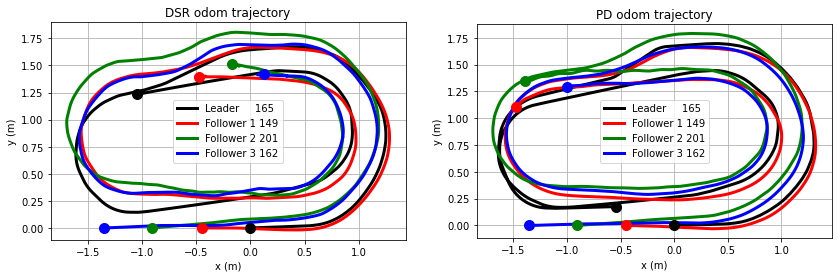

In [153]:
odom165_data_dsr = pd.read_csv(readbag_dsr.message_by_topic('/tbot165/odom'))
posx165_dsr = odom165_data_dsr['pose.pose.position.x'].to_numpy()
posy165_dsr = odom165_data_dsr['pose.pose.position.y'].to_numpy()
odom165_data_pds = pd.read_csv(readbag_pds.message_by_topic('/tbot165/odom'))
posx165_pds = odom165_data_pds['pose.pose.position.x'].to_numpy()
posy165_pds = odom165_data_pds['pose.pose.position.y'].to_numpy()

odom149_data_dsr = pd.read_csv(readbag_dsr.message_by_topic('/tbot149/odom'))
posx149_dsr = odom149_data_dsr['pose.pose.position.x'].to_numpy()
posy149_dsr = odom149_data_dsr['pose.pose.position.y'].to_numpy()
odom149_data_pds = pd.read_csv(readbag_pds.message_by_topic('/tbot149/odom'))
posx149_pds = odom149_data_pds['pose.pose.position.x'].to_numpy()
posy149_pds = odom149_data_pds['pose.pose.position.y'].to_numpy()

odom201_data_dsr = pd.read_csv(readbag_dsr.message_by_topic('/tbot201/odom'))
posx201_dsr = odom201_data_dsr['pose.pose.position.x'].to_numpy()
posy201_dsr = odom201_data_dsr['pose.pose.position.y'].to_numpy()
odom201_data_pds = pd.read_csv(readbag_pds.message_by_topic('/tbot201/odom'))
posx201_pds = odom201_data_pds['pose.pose.position.x'].to_numpy()
posy201_pds = odom201_data_pds['pose.pose.position.y'].to_numpy()

odom162_data_dsr = pd.read_csv(readbag_dsr.message_by_topic('/tbot162/odom'))
posx162_dsr = odom162_data_dsr['pose.pose.position.x'].to_numpy()
posy162_dsr = odom162_data_dsr['pose.pose.position.y'].to_numpy()
odom162_data_pds = pd.read_csv(readbag_pds.message_by_topic('/tbot162/odom'))
posx162_pds = odom162_data_pds['pose.pose.position.x'].to_numpy()
posy162_pds = odom162_data_pds['pose.pose.position.y'].to_numpy()

d = 0.45

fig, (ax1, ax2) = plt.subplots(1,2,figsize=(14,6))
ax1.plot(posx165_dsr,     posy165_dsr,'k-', linewidth=3,label='Leader     165')
ax1.plot(posx149_dsr-d,   posy149_dsr,'r-', linewidth=3,label='Follower 1 149')
ax1.plot(posx201_dsr-2*d, posy201_dsr,'g-', linewidth=3,label='Follower 2 201')
ax1.plot(posx162_dsr-3*d, posy162_dsr,'b-', linewidth=3,label='Follower 3 162')
ax1.plot(posx165_dsr[0],     posy165_dsr[0],'ko', markersize=10)
ax1.plot(posx149_dsr[0]-d,   posy149_dsr[0],'ro', markersize=10)
ax1.plot(posx201_dsr[0]-2*d, posy201_dsr[0],'go', markersize=10)
ax1.plot(posx162_dsr[0]-3*d, posy162_dsr[0],'bo', markersize=10)
ax1.plot(posx165_dsr[-1],     posy165_dsr[-1],'ko', markersize=10)
ax1.plot(posx149_dsr[-1]-d,   posy149_dsr[-1],'ro', markersize=10)
ax1.plot(posx201_dsr[-1]-2*d, posy201_dsr[-1],'go', markersize=10)
ax1.plot(posx162_dsr[-1]-3*d, posy162_dsr[-1],'bo', markersize=10)
ax1.set_xlabel('x (m)')
ax1.set_ylabel('y (m)')
ax1.set_aspect('equal')
ax1.set_title('DSR odom trajectory')
ax1.legend()
ax1.grid()

ax2.plot(posx165_pds,     posy165_pds,'k-', linewidth=3,label='Leader     165')
ax2.plot(posx149_pds-d,   posy149_pds,'r-', linewidth=3,label='Follower 1 149')
ax2.plot(posx201_pds-2*d, posy201_pds,'g-', linewidth=3,label='Follower 2 201')
ax2.plot(posx162_pds-3*d, posy162_pds,'b-', linewidth=3,label='Follower 3 162')
ax2.plot(posx165_pds[0],     posy165_pds[0],'ko', markersize=10)
ax2.plot(posx149_pds[0]-d,   posy149_pds[0],'ro', markersize=10)
ax2.plot(posx201_pds[0]-2*d, posy201_pds[0],'go', markersize=10)
ax2.plot(posx162_pds[0]-3*d, posy162_pds[0],'bo', markersize=10)
ax2.plot(posx165_pds[-1],     posy165_pds[-1],'ko', markersize=10)
ax2.plot(posx149_pds[-1]-d,   posy149_pds[-1],'ro', markersize=10)
ax2.plot(posx201_pds[-1]-2*d, posy201_pds[-1],'go', markersize=10)
ax2.plot(posx162_pds[-1]-3*d, posy162_pds[-1],'bo', markersize=10)
ax2.set_xlabel('x (m)')
ax2.set_ylabel('y (m)')
ax2.set_aspect('equal')
ax2.set_title('PD odom trajectory')
ax2.legend()
ax2.grid()

### Plot spacing error

data149 dsr duration: 213.9924120903015 data length: 2141
data149 pds duration: 255.20420289039612 data length: 2553
data201 dsr duration: 213.92034792900085 data length: 1987
data201 pds duration: 255.12489938735962 data length: 1955
data162 dsr duration: 213.90442848205566 data length: 2140
data162 pds duration: 255.18761324882507 data length: 2553


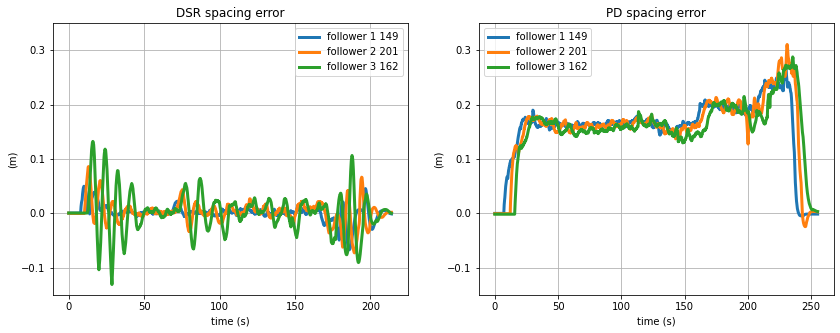

In [154]:
data149_data_dsr = pd.read_csv(readbag_dsr.message_by_topic('/tbot149/data'))
data149_t_dsr = data149_data_dsr['Time'].to_numpy()
data149_t_dsr = data149_t_dsr-data149_t_dsr[0]   # plot this
spacing_e149_dsr = data149_data_dsr['linear.x']  # plot this
print('data149 dsr duration:', max(data149_t_dsr)-min(data149_t_dsr), 'data length:', len(data149_t_dsr))
data149_data_pds = pd.read_csv(readbag_pds.message_by_topic('/tbot149/data'))
data149_t_pds = data149_data_pds['Time'].to_numpy()
data149_t_pds = data149_t_pds-data149_t_pds[0]   # plot this
spacing_e149_pds = data149_data_pds['linear.x']  # plot this
print('data149 pds duration:', max(data149_t_pds)-min(data149_t_pds), 'data length:', len(data149_t_pds))

data201_data_dsr = pd.read_csv(readbag_dsr.message_by_topic('/tbot201/data'))
data201_t_dsr = data201_data_dsr['Time'].to_numpy()
data201_t_dsr = data201_t_dsr-data201_t_dsr[0]   # plot this
spacing_e201_dsr = data201_data_dsr['linear.x']  # plot this
print('data201 dsr duration:', max(data201_t_dsr)-min(data201_t_dsr), 'data length:', len(data201_t_dsr))
data201_data_pds = pd.read_csv(readbag_pds.message_by_topic('/tbot201/data'))
data201_t_pds = data201_data_pds['Time'].to_numpy()
data201_t_pds = data201_t_pds-data201_t_pds[0]   # plot this
spacing_e201_pds = data201_data_pds['linear.x']  # plot this
print('data201 pds duration:', max(data201_t_pds)-min(data201_t_pds), 'data length:', len(data201_t_pds))

data162_data_dsr = pd.read_csv(readbag_dsr.message_by_topic('/tbot162/data'))
data162_t_dsr = data162_data_dsr['Time'].to_numpy()
data162_t_dsr = data162_t_dsr-data162_t_dsr[0]   # plot this
spacing_e162_dsr = data162_data_dsr['linear.x']  # plot this
print('data162 dsr duration:', max(data162_t_dsr)-min(data162_t_dsr), 'data length:', len(data162_t_dsr))
data162_data_pds = pd.read_csv(readbag_pds.message_by_topic('/tbot162/data'))
data162_t_pds = data162_data_pds['Time'].to_numpy()
data162_t_pds = data162_t_pds-data162_t_pds[0]   # plot this
spacing_e162_pds = data162_data_pds['linear.x']  # plot this
print('data162 pds duration:', max(data162_t_pds)-min(data162_t_pds), 'data length:', len(data162_t_pds))

fig, (ax1, ax2) = plt.subplots(1,2,figsize=(14,5))
ax1.plot(data149_t_dsr, spacing_e149_dsr,'-', linewidth=3, label='follower 1 149')
ax1.plot(data201_t_dsr, spacing_e201_dsr,'-', linewidth=3, label='follower 2 201')
ax1.plot(data162_t_dsr, spacing_e162_dsr,'-', linewidth=3, label='follower 3 162')
ax1.set_title('DSR spacing error')
ax1.set_ylim(-0.15, 0.35)
ax1.set_xlabel('time (s)')
ax1.set_ylabel('(m)')
ax1.legend()
ax1.grid()

ax2.plot(data149_t_pds, spacing_e149_pds,'-', linewidth=3, label='follower 1 149')
ax2.plot(data201_t_pds, spacing_e201_pds,'-', linewidth=3, label='follower 2 201')
ax2.plot(data162_t_pds, spacing_e162_pds,'-', linewidth=3, label='follower 3 162')
ax2.set_title('PD spacing error')
ax2.set_ylim(-0.15, 0.35)
ax2.set_xlabel('time (s)')
ax2.set_ylabel('(m)')
ax2.legend()
ax2.grid()

### Odom time stamp check

odom165 dsr duration: 214.0490448474884 data length: 5656
odom165 pds duration: 255.26349020004272 data length: 6768
odom149 dsr duration: 213.97775077819824 data length: 4686
odom149 pds duration: 255.28887629508972 data length: 6370
odom201 dsr duration: 213.98371481895447 data length: 2974
odom201 pds duration: 255.11932468414307 data length: 3629
odom162 dsr duration: 214.05584478378296 data length: 5234
odom149 pds duration: 255.2737159729004 data length: 6115


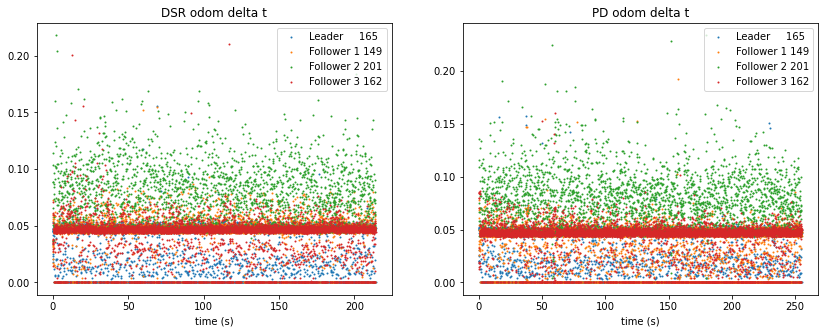

In [168]:
odom165_t_dsr = odom165_data_dsr['Time'].to_numpy()
odom165_t_dsr = odom165_t_dsr-odom165_t_dsr[0]
print('odom165 dsr duration:', max(odom165_t_dsr)-min(odom165_t_dsr), 'data length:', len(odom165_t_dsr))
odom165_t_pds = odom165_data_pds['Time'].to_numpy()
odom165_t_pds = odom165_t_pds-odom165_t_pds[0]
print('odom165 pds duration:', max(odom165_t_pds)-min(odom165_t_pds), 'data length:', len(odom165_t_pds))

odom149_t_dsr = odom149_data_dsr['Time'].to_numpy()
odom149_t_dsr = odom149_t_dsr-odom149_t_dsr[0]
print('odom149 dsr duration:', max(odom149_t_dsr)-min(odom149_t_dsr), 'data length:', len(odom149_t_dsr))
odom149_t_pds = odom149_data_pds['Time'].to_numpy()
odom149_t_pds = odom149_t_pds-odom149_t_pds[0]
print('odom149 pds duration:', max(odom149_t_pds)-min(odom149_t_pds), 'data length:', len(odom149_t_pds))

odom201_t_dsr = odom201_data_dsr['Time'].to_numpy()
odom201_t_dsr = odom201_t_dsr-odom201_t_dsr[0]
print('odom201 dsr duration:', max(odom201_t_dsr)-min(odom201_t_dsr), 'data length:', len(odom201_t_dsr))
odom201_t_pds = odom201_data_pds['Time'].to_numpy()
odom201_t_pds = odom201_t_pds-odom201_t_pds[0]
print('odom201 pds duration:', max(odom201_t_pds)-min(odom201_t_pds), 'data length:', len(odom201_t_pds))

odom162_t_dsr = odom162_data_dsr['Time'].to_numpy()
odom162_t_dsr = odom162_t_dsr-odom162_t_dsr[0]
print('odom162 dsr duration:', max(odom162_t_dsr)-min(odom162_t_dsr), 'data length:', len(odom162_t_dsr))
odom162_t_pds = odom162_data_pds['Time'].to_numpy()
odom162_t_pds = odom162_t_pds-odom162_t_pds[0]
print('odom149 pds duration:', max(odom162_t_pds)-min(odom162_t_pds), 'data length:', len(odom162_t_pds))

fig, (ax1, ax2) = plt.subplots(1,2,figsize=(14,5))
ax1.plot(odom165_t_dsr[:-1], np.diff(odom165_t_dsr), '.', markersize='2', label='Leader     165')
ax1.plot(odom149_t_dsr[:-1], np.diff(odom149_t_dsr), '.', markersize='2', label='Follower 1 149')
ax1.plot(odom201_t_dsr[:-1], np.diff(odom201_t_dsr), '.', markersize='2', label='Follower 2 201')
ax1.plot(odom162_t_dsr[:-1], np.diff(odom162_t_dsr), '.', markersize='2', label='Follower 3 162')
ax1.set_xlabel('time (s)')
ax1.set_title('DSR odom delta t')
ax1.legend()

ax2.plot(odom165_t_pds[:-1], np.diff(odom165_t_pds), '.', markersize='2', label='Leader     165')
ax2.plot(odom149_t_pds[:-1], np.diff(odom149_t_pds), '.', markersize='2', label='Follower 1 149')
ax2.plot(odom201_t_pds[:-1], np.diff(odom201_t_pds), '.', markersize='2', label='Follower 2 201')
ax2.plot(odom162_t_pds[:-1], np.diff(odom162_t_pds), '.', markersize='2', label='Follower 3 162')
ax2.set_xlabel('time (s)')
ax2.set_title('PD odom delta t')
ax2.legend()

### Plot velocity

In [188]:
def lowPass(input, lowPassGain=0.05):

    output = np.zeros(len(input))
    output[0] = input[0]

    for i in range(len(input)-1):
        output[i+1] = lowPassGain*input[i+1] + (1-lowPassGain)*input[i]

    return output

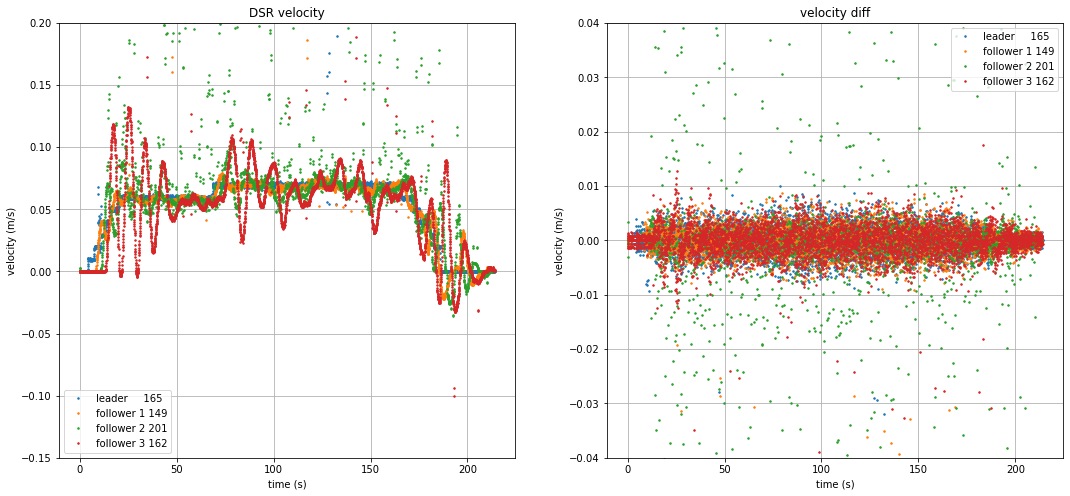

In [230]:
odom165_data_dsr = pd.read_csv(readbag_dsr.message_by_topic('/tbot165/odom'))
velx165_dsr = odom165_data_dsr['twist.twist.linear.x'].to_numpy() # plot this
odom165_data_pds = pd.read_csv(readbag_pds.message_by_topic('/tbot165/odom'))
velx165_pds = odom165_data_pds['twist.twist.linear.x'].to_numpy() # plot this

odom149_data_dsr = pd.read_csv(readbag_dsr.message_by_topic('/tbot149/odom'))
velx149_dsr = odom149_data_dsr['twist.twist.linear.x'].to_numpy() # plot this
odom149_data_pds = pd.read_csv(readbag_pds.message_by_topic('/tbot149/odom'))
velx149_pds = odom149_data_pds['twist.twist.linear.x'].to_numpy() # plot this

odom201_data_dsr = pd.read_csv(readbag_dsr.message_by_topic('/tbot201/odom'))
velx201_dsr = odom201_data_dsr['twist.twist.linear.x'].to_numpy() # plot this
odom201_data_pds = pd.read_csv(readbag_pds.message_by_topic('/tbot201/odom'))
velx201_pds = odom201_data_pds['twist.twist.linear.x'].to_numpy() # plot this

odom162_data_dsr = pd.read_csv(readbag_dsr.message_by_topic('/tbot162/odom'))
velx162_dsr = odom162_data_dsr['twist.twist.linear.x'].to_numpy() # plot this
odom162_data_pds = pd.read_csv(readbag_pds.message_by_topic('/tbot162/odom'))
velx162_pds = odom162_data_pds['twist.twist.linear.x'].to_numpy() # plot this

gain = 0.5

fig, (ax1, ax2) = plt.subplots(1,2,figsize=(18,8))
ax1.plot(odom165_t_dsr, lowPass(velx165_dsr, lowPassGain=gain),'.', markersize=3, label='leader     165')
ax1.plot(odom149_t_dsr, lowPass(velx149_dsr, lowPassGain=gain),'.', markersize=3, label='follower 1 149')
ax1.plot(odom201_t_dsr, lowPass(velx201_dsr, lowPassGain=gain),'.', markersize=3, label='follower 2 201')
ax1.plot(odom162_t_dsr, lowPass(velx162_dsr, lowPassGain=gain),'.', markersize=3, label='follower 3 162')
ax1.set_xlabel('time (s)')
ax1.set_ylabel('velocity (m/s)')
ax1.set_title('DSR velocity')
ax1.set_ylim(-0.15, 0.2)
ax1.legend()
ax1.grid()

gain = 1.0

ax2.plot(odom165_t_dsr[:-1], lowPass(np.diff(velx165_dsr), lowPassGain=gain),'.', markersize=3, label='leader     165')
ax2.plot(odom149_t_dsr[:-1], lowPass(np.diff(velx149_dsr), lowPassGain=gain),'.', markersize=3, label='follower 1 149')
ax2.plot(odom201_t_dsr[:-1], lowPass(np.diff(velx201_dsr), lowPassGain=gain),'.', markersize=3, label='follower 2 201')
ax2.plot(odom162_t_dsr[:-1], lowPass(np.diff(velx162_dsr), lowPassGain=gain),'.', markersize=3, label='follower 3 162')
ax2.set_xlabel('time (s)')
ax2.set_ylabel('velocity (m/s)')
ax2.set_title('velocity diff')
ax2.set_ylim(-0.04, 0.04)
ax2.legend()
ax2.grid()

In [ ]:
'''
1. lowpass velocity (gain 0.5)
2. if vel>0.15, vel=self.v
3. if np.abs(vel-vel_last)>
'''

### Plot relative angle

In [156]:
def zoh(input_time, input_array, total_time=250, dt=0.025):
    
    steps = int(total_time/dt)
    output_array = np.zeros(steps)
    output_time  = np.linspace(0, total_time, steps)

    for i in range(len(output_time)):
        idx = np.searchsorted(input_time, output_time[i], side='left')
        if idx > 0 and idx == len(input_array):
            output_array[i] = input_array[idx-1]
        else:
            output_array[i] = input_array[idx]

    return output_time, output_array

def toDegree(rad):

    return rad*180/np.pi

def filter180(array, threshold=180):

    # get all indices that has values larger than 180
    indx_l_180 = np.nonzero(array<-180)
    indx_g_180 = np.nonzero(array>180)
    # asign previous index's value to these indices
    array[np.array(indx_l_180)] += 360
    array[np.array(indx_g_180)] -= 360

    return array

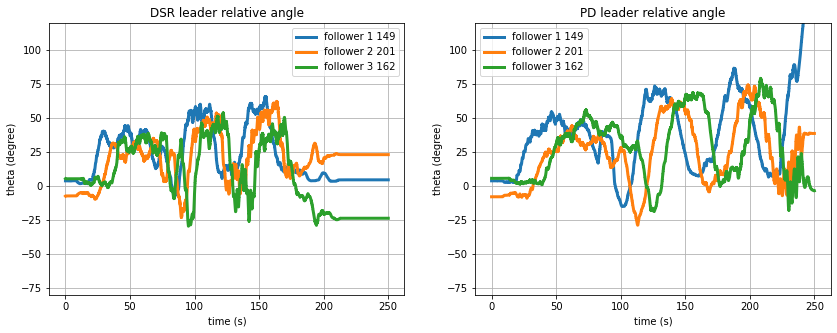

In [164]:
from scipy.spatial.transform import Rotation as R

r = R.from_quat(np.array([odom165_data_dsr['pose.pose.orientation.x'].to_numpy(),
                          odom165_data_dsr['pose.pose.orientation.y'].to_numpy(), 
                          odom165_data_dsr['pose.pose.orientation.z'].to_numpy(),
                          odom165_data_dsr['pose.pose.orientation.w'].to_numpy()]).T)
head165_dsr = r.as_euler('zyx', degrees=True)[:,0]
odom165_t_dsr_zoh, head165_dsr_zoh = zoh(odom165_t_dsr, head165_dsr) # plot this
r = R.from_quat(np.array([odom165_data_pds['pose.pose.orientation.x'].to_numpy(),
                          odom165_data_pds['pose.pose.orientation.y'].to_numpy(), 
                          odom165_data_pds['pose.pose.orientation.z'].to_numpy(),
                          odom165_data_pds['pose.pose.orientation.w'].to_numpy()]).T)
head165_pds = r.as_euler('zyx', degrees=True)[:,0]
odom165_t_pds_zoh, head165_pds_zoh = zoh(odom165_t_pds, head165_pds) # plot this

r = R.from_quat(np.array([odom149_data_dsr['pose.pose.orientation.x'].to_numpy(),
                          odom149_data_dsr['pose.pose.orientation.y'].to_numpy(), 
                          odom149_data_dsr['pose.pose.orientation.z'].to_numpy(),
                          odom149_data_dsr['pose.pose.orientation.w'].to_numpy()]).T)
head149_dsr = r.as_euler('zyx', degrees=True)[:,0]
odom149_t_dsr_zoh, head149_dsr_zoh = zoh(odom149_t_dsr, head149_dsr) # plot this
r = R.from_quat(np.array([odom149_data_pds['pose.pose.orientation.x'].to_numpy(),
                          odom149_data_pds['pose.pose.orientation.y'].to_numpy(), 
                          odom149_data_pds['pose.pose.orientation.z'].to_numpy(),
                          odom149_data_pds['pose.pose.orientation.w'].to_numpy()]).T)
head149_pds = r.as_euler('zyx', degrees=True)[:,0]
odom149_t_pds_zoh, head149_pds_zoh = zoh(odom149_t_pds, head149_pds) # plot this

r = R.from_quat(np.array([odom201_data_dsr['pose.pose.orientation.x'].to_numpy(),
                          odom201_data_dsr['pose.pose.orientation.y'].to_numpy(), 
                          odom201_data_dsr['pose.pose.orientation.z'].to_numpy(),
                          odom201_data_dsr['pose.pose.orientation.w'].to_numpy()]).T)
head201_dsr = r.as_euler('zyx', degrees=True)[:,0]
odom201_t_dsr_zoh, head201_dsr_zoh = zoh(odom201_t_dsr, head201_dsr) # plot this
r = R.from_quat(np.array([odom201_data_pds['pose.pose.orientation.x'].to_numpy(),
                          odom201_data_pds['pose.pose.orientation.y'].to_numpy(), 
                          odom201_data_pds['pose.pose.orientation.z'].to_numpy(),
                          odom201_data_pds['pose.pose.orientation.w'].to_numpy()]).T)
head201_pds = r.as_euler('zyx', degrees=True)[:,0]
odom201_t_pds_zoh, head201_pds_zoh = zoh(odom201_t_pds, head201_pds) # plot this

r = R.from_quat(np.array([odom162_data_dsr['pose.pose.orientation.x'].to_numpy(),
                          odom162_data_dsr['pose.pose.orientation.y'].to_numpy(), 
                          odom162_data_dsr['pose.pose.orientation.z'].to_numpy(),
                          odom162_data_dsr['pose.pose.orientation.w'].to_numpy()]).T)
head162_dsr = r.as_euler('zyx', degrees=True)[:,0]
odom162_t_dsr_zoh, head162_dsr_zoh = zoh(odom162_t_dsr, head162_dsr) # plot this
r = R.from_quat(np.array([odom162_data_pds['pose.pose.orientation.x'].to_numpy(),
                          odom162_data_pds['pose.pose.orientation.y'].to_numpy(), 
                          odom162_data_pds['pose.pose.orientation.z'].to_numpy(),
                          odom162_data_pds['pose.pose.orientation.w'].to_numpy()]).T)
head162_pds = r.as_euler('zyx', degrees=True)[:,0]
odom162_t_pds_zoh, head162_pds_zoh = zoh(odom162_t_pds, head162_pds) # plot this

fig, (ax1, ax2) = plt.subplots(1,2,figsize=(14,5))
ax1.plot(odom149_t_dsr_zoh, filter180(head165_dsr_zoh-head149_dsr_zoh), '-', linewidth=3, label='follower 1 149')
ax1.plot(odom201_t_dsr_zoh, filter180(head149_dsr_zoh-head201_dsr_zoh), '-', linewidth=3, label='follower 2 201')
ax1.plot(odom162_t_dsr_zoh, filter180(head201_dsr_zoh-head162_dsr_zoh), '-', linewidth=3, label='follower 3 162')
ax1.set_title('DSR leader relative angle')
ax1.set_xlabel('time (s)')
ax1.set_ylabel('theta (degree)')
ax1.set_ylim(-80, 120)
ax1.legend()
ax1.grid()

ax2.plot(odom149_t_pds_zoh, filter180(head165_pds_zoh-head149_pds_zoh), '-', linewidth=3, label='follower 1 149')
ax2.plot(odom201_t_pds_zoh, filter180(head149_pds_zoh-head201_pds_zoh), '-', linewidth=3, label='follower 2 201')
ax2.plot(odom162_t_pds_zoh, filter180(head201_pds_zoh-head162_pds_zoh), '-', linewidth=3, label='follower 3 162')
ax2.set_title('PD leader relative angle')
ax2.set_xlabel('time (s)')
ax2.set_ylabel('theta (degree)')
ax2.set_ylim(-80, 120)
ax2.legend()
ax2.grid()

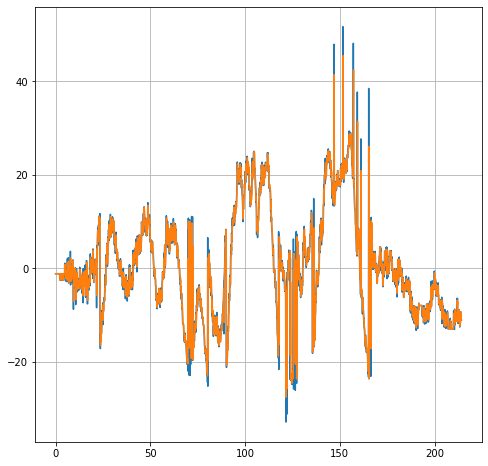

In [158]:
sensing149_data = pd.read_csv(readbag_dsr.message_by_topic('/tbot149/april_data_multi'), on_bad_lines='skip')
sensing149_freq = readbag_dsr.topic_table['Frequency'][0]
leader_phi_149  = sensing149_data['data_4'].to_numpy()


sensing201_data = pd.read_csv(readbag_dsr.message_by_topic('/tbot201/april_data_multi'), on_bad_lines='skip')
sensing201_freq = readbag_dsr.topic_table['Frequency'][11]
leader_phi_201  = sensing201_data['data_4'].to_numpy()


sensing162_data = pd.read_csv(readbag_dsr.message_by_topic('/tbot162/april_data_multi'), on_bad_lines='skip')
sensing162_freq = readbag_dsr.topic_table['Frequency'][5]
leader_phi_162  = sensing162_data['data_4'].to_numpy()

def lowPass(u, y_last, lowPassGain=0.2):

    return lowPassGain*u + (1-lowPassGain)*y_last 

leader_phi_149_lowpass = np.zeros(len(leader_phi_149))
leader_phi_149_last = leader_phi_149[0]
for i in range(len(leader_phi_149)):

    leader_phi_149_lowpass[i] = lowPass(leader_phi_149[i], leader_phi_149_last, lowPassGain=0.2)
    leader_phi_149_last = leader_phi_149[i]

plt.figure(figsize=(8,8))
plt.plot(np.arange(len(leader_phi_149))/sensing149_freq, leader_phi_149*180/np.pi)
plt.plot(np.arange(len(leader_phi_149))/sensing149_freq, leader_phi_149_lowpass*180/np.pi)
# plt.plot(np.arange(len(leader_phi_201))/sensing201_freq, leader_phi_201*180/np.pi)
# plt.plot(np.arange(len(leader_phi_162))/sensing162_freq, leader_phi_162*180/np.pi)
plt.grid()